In [ ]:
# ============================================================
# CELLA 1: Installazione dipendenze
# Installiamo kaggle per scaricare il dataset PlantVillage
# ============================================================

!pip install kaggle --quiet

# Verifichiamo le versioni delle librerie principali
import cv2
import numpy as np
import matplotlib
import torch
import sklearn

print(f"OpenCV: {cv2.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Matplotlib: {matplotlib.__version__}")
print(f"PyTorch: {torch.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")

# Verifichiamo se la GPU è disponibile (fondamentale per il Giorno 4)
print(f"\nGPU disponibile: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

OpenCV: 4.13.0
NumPy: 2.0.2
Matplotlib: 3.10.0
PyTorch: 2.11.0+cu128
Scikit-learn: 1.6.1

GPU disponibile: True
GPU: Tesla T4


In [ ]:
# ============================================================
# CELLA 2: Configurazione Kaggle API con token diretto
# Nuovo metodo Kaggle 2024+ (senza file kaggle.json)
# ============================================================

import os

# Creiamo la directory .kaggle
os.makedirs('/root/.kaggle', exist_ok=True)

# Scriviamo il file di configurazione direttamente
# SOSTITUISCI con il tuo username Kaggle e il token che hai generato
KAGGLE_USERNAME = "tommasobrigaglia"   # ← metti il tuo username
KAGGLE_TOKEN    = "KGAT_1f1f079cf532ebdd034c2f164c6b88c3"                  # ← incolla qui il token (solo in Colab, mai su GitHub!)

# Creiamo il file kaggle.json manualmente
import json

kaggle_config = {
    "username": KAGGLE_USERNAME,
    "key": KAGGLE_TOKEN
}

with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_config, f)

# Permessi corretti (obbligatori per Kaggle)
!chmod 600 /root/.kaggle/kaggle.json

# Verifica
!kaggle datasets list --search "plant-village" 2>&1 | head -5
print("✅ Kaggle API configurata!")

ref                                                                     title                                                      size  lastUpdated                 downloadCount  voteCount  usabilityRating  
----------------------------------------------------------------------  --------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
arjuntejaswi/plant-village                                              Plant Village                                         344488049  2019-11-14 05:37:32.860000          52767        380  0.1875           
tushar5harma/plant-village-dataset-updated                              Plant Village Dataset (Updated)                      1076224061  2023-04-18 04:33:25.507000           7480         59  0.75             
adilmubashirchaudhry/plant-village-dataset                              Plant Village Dataset                                1036791049  2023-09-08 20:51:29.697000 

In [ ]:
# ============================================================
# CELLA 3: Download dataset PlantVillage da Kaggle
# Usiamo solo le classi di pomodoro per semplicità
# ============================================================

# Creiamo la directory principale del progetto
os.makedirs('/content/plant_disease_project', exist_ok=True)
os.chdir('/content/plant_disease_project')

# Download del dataset PlantVillage
# Nota: il dataset completo è ~1.5GB, ci vuole qualche minuto
print("Scaricando PlantVillage... (potrebbe richiedere 2-3 minuti)")
!kaggle datasets download -d arjuntejaswi/plant-village --quiet

# Estraiamo l'archivio
print("Estraendo i file...")
!unzip -q plant-village.zip -d plant_village_raw

print("✅ Dataset scaricato ed estratto!")

# Verifichiamo la struttura delle cartelle
!ls plant_village_raw/

Scaricando PlantVillage... (potrebbe richiedere 2-3 minuti)
Dataset URL: https://www.kaggle.com/datasets/arjuntejaswi/plant-village
License(s): unknown
Estraendo i file...
✅ Dataset scaricato ed estratto!
PlantVillage


In [ ]:
# ============================================================
# CELLA 4: Selezione classi target — nomi verificati dal Data Explorer
# Scelta metodologica: 3 classi visivamente distinte di pomodoro
# ============================================================

import shutil, os

# Nomi ESATTI come nel dataset (underscore singolo, verificato)
CLASSI_TARGET = [
    'Tomato_healthy',       # foglia sana — classe di riferimento
    'Tomato_Early_blight',  # macchie scure con anelli concentrici
    'Tomato_Late_blight'    # lesioni grigio-brune, più aggressiva
]

# ATTENZIONE: la cartella estratta ha una sottocartella PlantVillage/
DIR_RAW     = '/content/plant_disease_project/plant_village_raw/PlantVillage'
DIR_DATASET = '/content/plant_disease_project/dataset'

os.makedirs(DIR_DATASET, exist_ok=True)

# Verifica che le cartelle esistano prima di procedere
print("Verifica classi disponibili:")
for classe in CLASSI_TARGET:
    percorso = os.path.join(DIR_RAW, classe)
    esiste = os.path.exists(percorso)
    n = len(os.listdir(percorso)) if esiste else 0
    stato = "✅" if esiste else "❌ NON TROVATA"
    print(f"  {stato} {classe}: {n} immagini")

Verifica classi disponibili:
  ✅ Tomato_healthy: 1591 immagini
  ✅ Tomato_Early_blight: 1000 immagini
  ✅ Tomato_Late_blight: 1909 immagini


In [ ]:
# ============================================================
# CELLA 5: Copiamo solo le 3 classi target in una cartella pulita
# Questa sarà la nostra working directory per tutto il progetto
# ============================================================

for classe in CLASSI_TARGET:
    percorso_sorgente    = os.path.join(DIR_RAW, classe)
    percorso_destinazione = os.path.join(DIR_DATASET, classe)

    # Evitiamo di ricopiare se esiste già (utile se rilanciamo la cella)
    if os.path.exists(percorso_destinazione):
        print(f"⏭️  {classe}: già presente, salto")
        continue

    if os.path.exists(percorso_sorgente):
        shutil.copytree(percorso_sorgente, percorso_destinazione)
        n = len(os.listdir(percorso_destinazione))
        print(f"✅ {classe}: {n} immagini copiate")
    else:
        print(f"❌ Errore: {classe} non trovata in {DIR_RAW}")

print("\n🎉 Dataset pronto in:", DIR_DATASET)

✅ Tomato_healthy: 1591 immagini copiate
✅ Tomato_Early_blight: 1000 immagini copiate
✅ Tomato_Late_blight: 1909 immagini copiate

🎉 Dataset pronto in: /content/plant_disease_project/dataset


📊 STATISTICHE DEL DATASET — PlantVillage (subset)
  Tomato_healthy: 1591 immagini
  Tomato_Early_blight: 1000 immagini
  Tomato_Late_blight: 1909 immagini

  TOTALE:  4500 immagini
  CLASSI:  3
  MEDIA:   1500 immagini per classe

  Classe più grande:  1909 immagini
  Classe più piccola: 1000 immagini
  Rapporto max/min:   1.91x → dataset bilanciato ✅


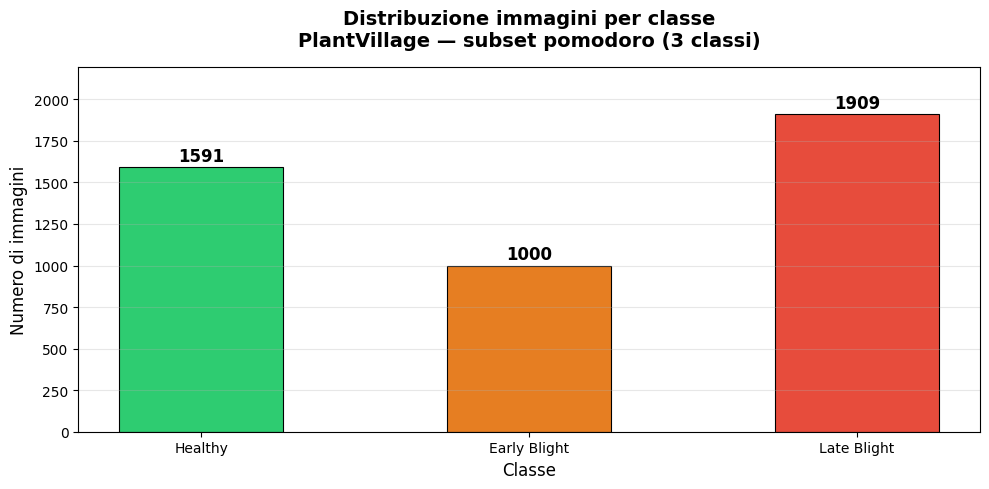

✅ Grafico salvato!


In [ ]:
# ============================================================
# CELLA 6: Analisi esplorativa (EDA) — distribuzione per classe
# Come visto nel Modulo 3: Step 1 della ML Pipeline è capire i dati
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

print("=" * 55)
print("📊 STATISTICHE DEL DATASET — PlantVillage (subset)")
print("=" * 55)

conteggio_classi = {}
totale = 0

for classe in CLASSI_TARGET:
    percorso = os.path.join(DIR_DATASET, classe)
    n = len([f for f in os.listdir(percorso)
             if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    conteggio_classi[classe] = n
    totale += n
    print(f"  {classe}: {n} immagini")

print(f"\n  TOTALE:  {totale} immagini")
print(f"  CLASSI:  {len(CLASSI_TARGET)}")
print(f"  MEDIA:   {totale // len(CLASSI_TARGET)} immagini per classe")

# Bilanciamento: calcoliamo quanto sono sbilanciate le classi
valori = list(conteggio_classi.values())
print(f"\n  Classe più grande:  {max(valori)} immagini")
print(f"  Classe più piccola: {min(valori)} immagini")
ratio = max(valori) / min(valori)
print(f"  Rapporto max/min:   {ratio:.2f}x", end=" ")
print("→ dataset bilanciato ✅" if ratio < 2 else "→ leggero sbilanciamento ⚠️")

# --- Grafico ---
fig, ax = plt.subplots(figsize=(10, 5))

nomi_brevi = ['Healthy', 'Early Blight', 'Late Blight']
colori     = ['#2ecc71', '#e67e22', '#e74c3c']

bars = ax.bar(nomi_brevi, valori, color=colori, edgecolor='black',
              linewidth=0.8, width=0.5)

# Valore sopra ogni barra
for bar, val in zip(bars, valori):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 15,
            str(val), ha='center', va='bottom',
            fontweight='bold', fontsize=12)

ax.set_title('Distribuzione immagini per classe\nPlantVillage — subset pomodoro (3 classi)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Classe', fontsize=12)
ax.set_ylabel('Numero di immagini', fontsize=12)
ax.set_ylim(0, max(valori) * 1.15)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/plant_disease_project/distribuzione_classi.png', dpi=150)
plt.show()
print("✅ Grafico salvato!")

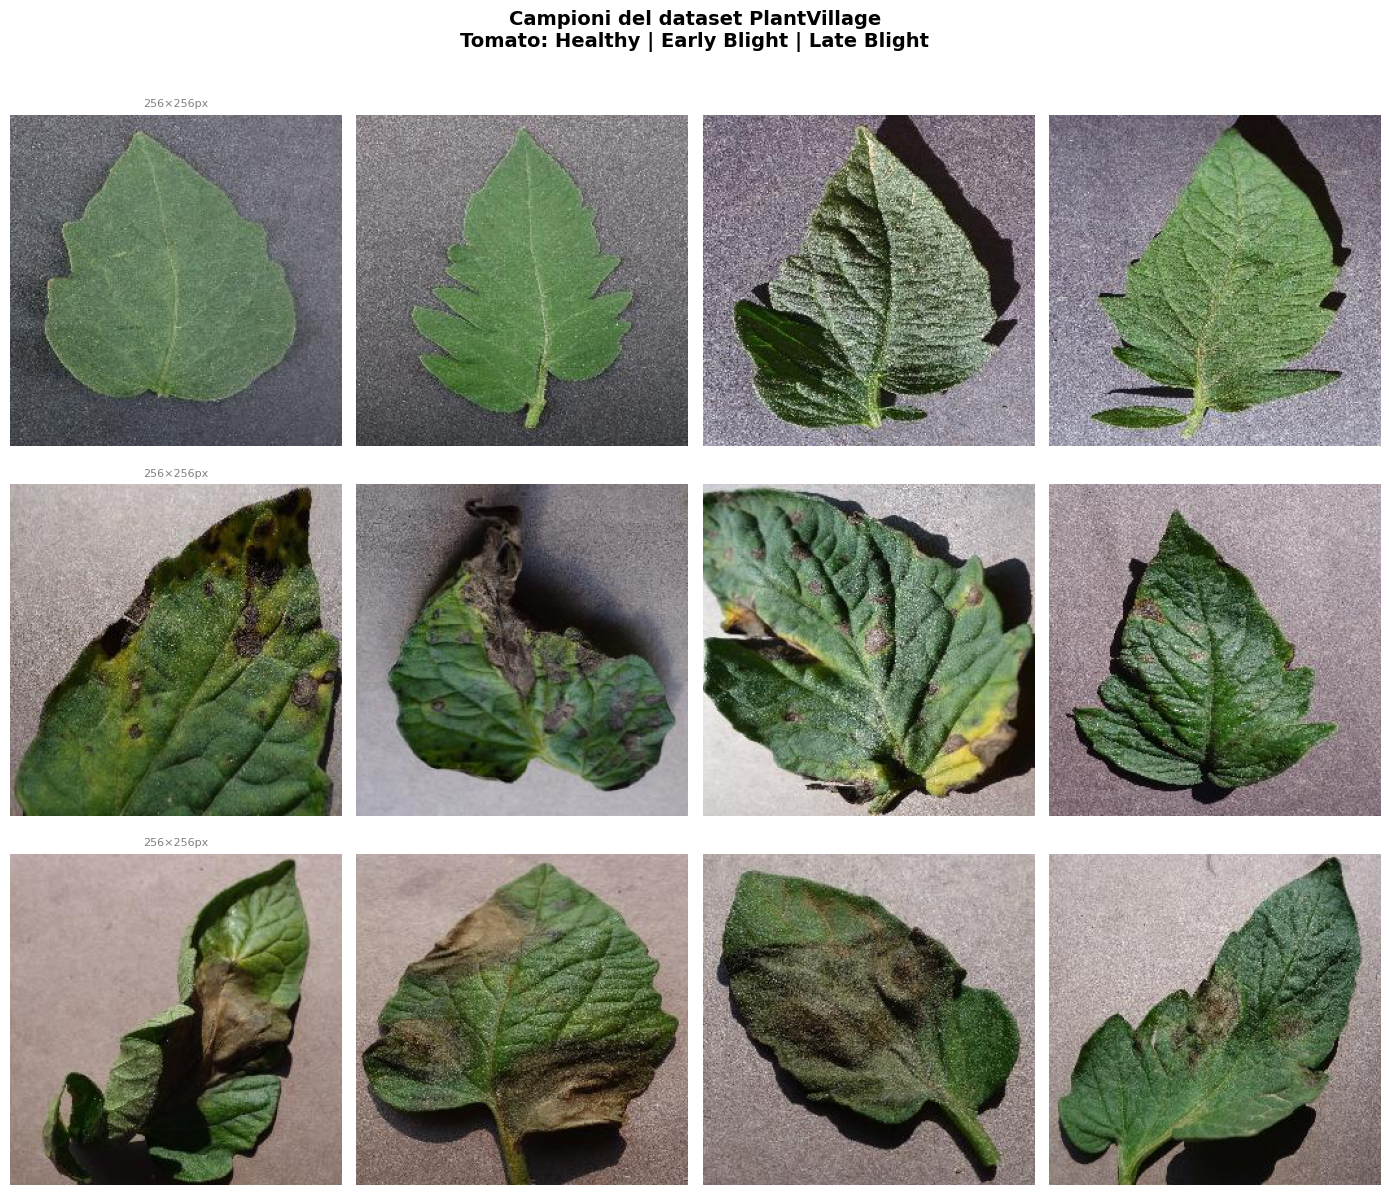

✅ Visualizzazione completata e salvata!


In [ ]:
# ============================================================
# CELLA 7: Visualizzazione campioni con OpenCV + Matplotlib
# CONCETTO CHIAVE (Modulo 1): OpenCV legge BGR → convertiamo in RGB
# In Colab: cv2_imshow invece di cv2.imshow
# ============================================================

import cv2
from google.colab.patches import cv2_imshow

N_PER_CLASSE = 4  # immagini da mostrare per ogni classe

fig, assi = plt.subplots(len(CLASSI_TARGET), N_PER_CLASSE,
                          figsize=(14, 4 * len(CLASSI_TARGET)))

etichette_y = ['Healthy', 'Early\nBlight', 'Late\nBlight']

for i, classe in enumerate(CLASSI_TARGET):
    percorso_classe = os.path.join(DIR_DATASET, classe)
    file_immagini   = sorted([
        f for f in os.listdir(percorso_classe)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ])[:N_PER_CLASSE]

    for j, nome_file in enumerate(file_immagini):
        percorso_img = os.path.join(percorso_classe, nome_file)

        # Lettura con OpenCV (formato BGR)
        img_bgr = cv2.imread(percorso_img)

        # ⚠️ CONVERSIONE OBBLIGATORIA: BGR → RGB per Matplotlib
        # Senza questa riga i rossi e i blu risultano invertiti
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        ax = assi[i][j]
        ax.imshow(img_rgb)
        ax.axis('off')

        # Stampiamo dimensioni solo sulla prima immagine di ogni classe
        if j == 0:
            h, w, c = img_bgr.shape
            ax.set_title(f'{w}×{h}px', fontsize=8, color='gray')
            ax.set_ylabel(etichette_y[i], fontsize=11,
                         fontweight='bold', rotation=0,
                         labelpad=60, va='center')

plt.suptitle('Campioni del dataset PlantVillage\nTomato: Healthy | Early Blight | Late Blight',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/plant_disease_project/campioni_dataset.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualizzazione completata e salvata!")

In [ ]:
# ============================================================
# CELLA 8: Analisi tecnica — dimensioni, statistiche pixel, bias
# Queste informazioni andranno nel Technical Analysis Document
# ============================================================

print("=" * 60)
print("📐 ANALISI TECNICA DEL DATASET")
print("=" * 60)

N_CAMPIONI  = 20  # analizziamo un campione per velocità
dimensioni  = []
pixel_medi  = []

for classe in CLASSI_TARGET:
    percorso_classe = os.path.join(DIR_DATASET, classe)
    file_lista = sorted([
        f for f in os.listdir(percorso_classe)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ])[:N_CAMPIONI]

    for nome_file in file_lista:
        img = cv2.imread(os.path.join(percorso_classe, nome_file))
        if img is not None:
            h, w = img.shape[:2]
            dimensioni.append((w, h))
            pixel_medi.append(img.mean())

# Risultati
dim_uniche = list(set(dimensioni))
print(f"\n📏 Dimensioni trovate: {len(dim_uniche)} variante/i")
for d in dim_uniche[:5]:
    print(f"   {d[0]}×{d[1]} pixel")

print(f"\n🎨 Statistiche pixel (range 0–255):")
print(f"   Media globale:  {np.mean(pixel_medi):.1f}")
print(f"   Dev. standard:  {np.std(pixel_medi):.1f}")
print(f"   Min:            {np.min(pixel_medi):.1f}")
print(f"   Max:            {np.max(pixel_medi):.1f}")

print("""
╔══════════════════════════════════════════════════════════╗
║  ⚠️  BIAS NOTO DEL DATASET — da citare nel documento    ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  PlantVillage è stato acquisito in laboratorio con       ║
║  sfondo uniforme (grigio/verde tinta unita).             ║
║                                                          ║
║  Rischio: il modello potrebbe classificare usando        ║
║  il background invece delle caratteristiche della        ║
║  foglia → scarsa generalizzazione in campo aperto.       ║
║                                                          ║
║  → Citare in: Failure Analysis + Ethical Considerations  ║
╚══════════════════════════════════════════════════════════╝
""")

print("✅ Analisi tecnica completata!")
print("\n📋 RIEPILOGO GIORNO 1:")
print(f"   Dataset: {sum(conteggio_classi.values())} immagini totali")
print(f"   Classi:  {len(CLASSI_TARGET)}")
print(f"   Dim. immagini: {dim_uniche[0][0]}×{dim_uniche[0][1]} px")
print("   Prossimo step → Giorno 2: Preprocessing (resize, normalize, augment)")

📐 ANALISI TECNICA DEL DATASET

📏 Dimensioni trovate: 1 variante/i
   256×256 pixel

🎨 Statistiche pixel (range 0–255):
   Media globale:  112.3
   Dev. standard:  16.9
   Min:            25.4
   Max:            150.8

╔══════════════════════════════════════════════════════════╗
║  ⚠️  BIAS NOTO DEL DATASET — da citare nel documento    ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  PlantVillage è stato acquisito in laboratorio con       ║
║  sfondo uniforme (grigio/verde tinta unita).             ║
║                                                          ║
║  Rischio: il modello potrebbe classificare usando        ║
║  il background invece delle caratteristiche della        ║
║  foglia → scarsa generalizzazione in campo aperto.       ║
║                                                          ║
║  → Citare in: Failure Analysis + Ethical Considerations  ║
╚══════════════════════════════════════════════════

In [ ]:
# ============================================================
# CELLA 9: Salvataggio su Google Drive
# IMPORTANTE: Colab resetta tutto alla scadenza della sessione!
# ============================================================

from google.colab import drive
import shutil, os

# Montiamo Google Drive
drive.mount('/content/drive')

# Cartella dedicata al progetto su Drive
DRIVE_DIR = '/content/drive/MyDrive/plant_disease_cv_project'
os.makedirs(DRIVE_DIR, exist_ok=True)

# Salviamo il dataset (la parte più importante)
DRIVE_DATASET = os.path.join(DRIVE_DIR, 'dataset')
if not os.path.exists(DRIVE_DATASET):
    print("Copiando dataset su Drive... (1-2 minuti)")
    shutil.copytree(
        '/content/plant_disease_project/dataset',
        DRIVE_DATASET
    )
    print("✅ Dataset salvato su Drive!")
else:
    print("⏭️  Dataset già presente su Drive, salto la copia")

# Salviamo i grafici generati oggi
grafici = ['distribuzione_classi.png', 'campioni_dataset.png']
for g in grafici:
    src = f'/content/plant_disease_project/{g}'
    dst = os.path.join(DRIVE_DIR, g)
    if os.path.exists(src):
        shutil.copy(src, dst)
        print(f"✅ Salvato: {g}")

print(f"\n📁 Tutto salvato in: {DRIVE_DIR}")
print("   La prossima sessione Colab: carica da Drive invece di riscaricare!")

Mounted at /content/drive
Copiando dataset su Drive... (1-2 minuti)
✅ Dataset salvato su Drive!
✅ Salvato: distribuzione_classi.png
✅ Salvato: campioni_dataset.png

📁 Tutto salvato in: /content/drive/MyDrive/plant_disease_cv_project
   La prossima sessione Colab: carica da Drive invece di riscaricare!
